In [25]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import evaluate

from IPython.display import display, Markdown

/opt/anaconda3/envs/dsci498/lib/python3.13/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [11]:
BASE_DIR = Path("../outputs")

MODEL_DIRS = {
    "Small BART": BASE_DIR / "qmsum_bart_baseline",
    "Large BART": BASE_DIR / "qmsum_large_bart",
}

for name, path in MODEL_DIRS.items():
    print(f"{name}: {path.exists()} -> {path}")
    print("Checkpoints:", list(path.glob("checkpoint-*")))
    print()

Small BART: True -> ../outputs/qmsum_bart_baseline
Checkpoints: [PosixPath('../outputs/qmsum_bart_baseline/checkpoint-2514'), PosixPath('../outputs/qmsum_bart_baseline/checkpoint-3771')]

Large BART: True -> ../outputs/qmsum_large_bart
Checkpoints: [PosixPath('../outputs/qmsum_large_bart/checkpoint-237'), PosixPath('../outputs/qmsum_large_bart/checkpoint-158')]



## Load trainer logs from checkpoints

In [12]:
def find_latest_trainer_state(model_dir):
    checkpoints = list(model_dir.glob("checkpoint-*"))

    if not checkpoints:
        print(f"No checkpoints found in {model_dir}")
        return None

    checkpoints = sorted(
        checkpoints,
        key=lambda p: int(p.name.split("-")[-1])
    )

    latest_checkpoint = checkpoints[-1]
    trainer_state = latest_checkpoint / "trainer_state.json"

    if not trainer_state.exists():
        print(f"No trainer_state.json found in {latest_checkpoint}")
        return None

    return trainer_state


def load_eval_logs(model_dir):
    trainer_state = find_latest_trainer_state(model_dir)

    if trainer_state is None:
        return pd.DataFrame()

    with open(trainer_state, "r", encoding="utf-8") as f:
        state = json.load(f)

    logs = pd.DataFrame(state["log_history"])

    eval_logs = logs[logs["eval_loss"].notna()].copy()

    return eval_logs

## Display raw validation logs

In [13]:
all_logs = {}

display(Markdown("# Validation Logs"))

for name, path in MODEL_DIRS.items():
    df = load_eval_logs(path)

    if df.empty:
        print(f"{name}: No eval logs found.")
        all_logs[name] = df
        continue

    df["Model"] = name
    all_logs[name] = df

    display(Markdown(f"## {name}"))
    display(df[["epoch", "eval_loss", "eval_rouge1", "eval_rouge2", "eval_rougeL"]])

# Validation Logs

## Small BART

,epoch,eval_loss,eval_rouge1,eval_rouge2,eval_rougeL
125,1.0,3.382565,0.3217,0.0905,0.2218
252,2.0,3.378520,0.3325,0.0932,0.2224
379,3.0,3.555228,0.3279,0.0900,0.2199


## Large BART

,epoch,eval_loss,eval_rouge1,eval_rouge2,eval_rougeL
7,1.0,3.101645,0.3341,0.0922,0.2142
16,2.0,3.066143,0.3457,0.0966,0.2196
25,3.0,3.070410,0.3403,0.0943,0.2139


## Plot validation ROUGE over epochs

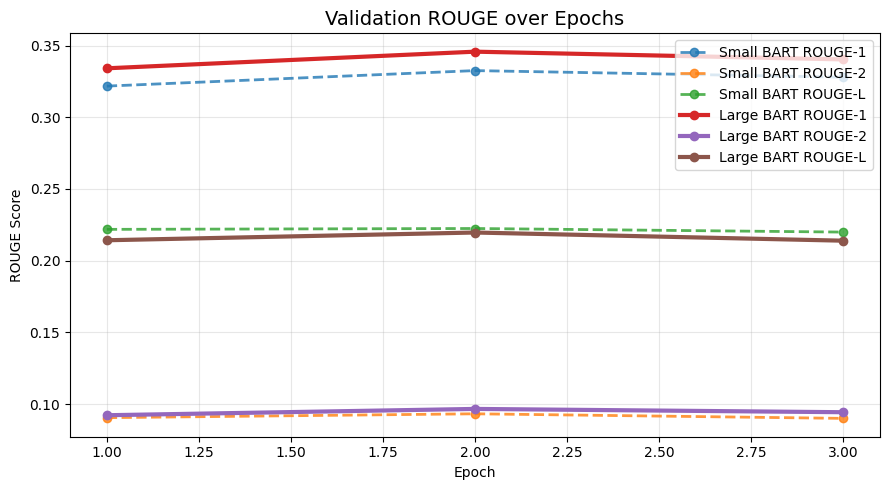

In [28]:
plt.figure(figsize=(9, 5))

for name, df in all_logs.items():
    if df.empty:
        continue

    if "Large" in name:
        # Bold solid lines for Large BART
        plt.plot(df["epoch"], df["eval_rouge1"],
                 marker="o", linewidth=3, linestyle="-",
                 label=f"{name} ROUGE-1")

        plt.plot(df["epoch"], df["eval_rouge2"],
                 marker="o", linewidth=3, linestyle="-",
                 label=f"{name} ROUGE-2")

        plt.plot(df["epoch"], df["eval_rougeL"],
                 marker="o", linewidth=3, linestyle="-",
                 label=f"{name} ROUGE-L")

    else:
        # Dashed lines for Small BART
        plt.plot(df["epoch"], df["eval_rouge1"],
                 marker="o", linewidth=2, linestyle="--",
                 alpha=0.8,
                 label=f"{name} ROUGE-1")

        plt.plot(df["epoch"], df["eval_rouge2"],
                 marker="o", linewidth=2, linestyle="--",
                 alpha=0.8,
                 label=f"{name} ROUGE-2")

        plt.plot(df["epoch"], df["eval_rougeL"],
                 marker="o", linewidth=2, linestyle="--",
                 alpha=0.8,
                 label=f"{name} ROUGE-L")

plt.title("Validation ROUGE over Epochs", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("ROUGE Score")

plt.grid(alpha=0.3)

plt.legend()
plt.tight_layout()
plt.show()

## Plot validation ROUGE over epochs

In [15]:
final_rows = []

for name, df in all_logs.items():
    if df.empty:
        continue

    last = df.iloc[-1]

    final_rows.append({
        "Model": name,
        "Eval Loss": last["eval_loss"],
        "ROUGE-1": last["eval_rouge1"],
        "ROUGE-2": last["eval_rouge2"],
        "ROUGE-L": last["eval_rougeL"],
    })

final_df = pd.DataFrame(final_rows)

display(Markdown("# Final Validation Comparison"))
display(final_df)

# Final Validation Comparison

,Model,Eval Loss,ROUGE-1,ROUGE-2,ROUGE-L
0,Small BART,3.555228,0.3279,0.0900,0.2199
1,Large BART,3.070410,0.3403,0.0943,0.2139


## Final validation comparison table

In [17]:
final_rows = []

for name, df in all_logs.items():
    if df.empty:
        continue

    last = df.iloc[-1]

    final_rows.append({
        "Model": name,
        "Eval Loss": last["eval_loss"],
        "ROUGE-1": last["eval_rouge1"],
        "ROUGE-2": last["eval_rouge2"],
        "ROUGE-L": last["eval_rougeL"],
    })

final_df = pd.DataFrame(final_rows)

display(Markdown("# Final Validation Comparison"))
display(final_df)

# Final Validation Comparison

,Model,Eval Loss,ROUGE-1,ROUGE-2,ROUGE-L
0,Small BART,3.555228,0.3279,0.0900,0.2199
1,Large BART,3.070410,0.3403,0.0943,0.2139


## Bar chart: final ROUGE comparison

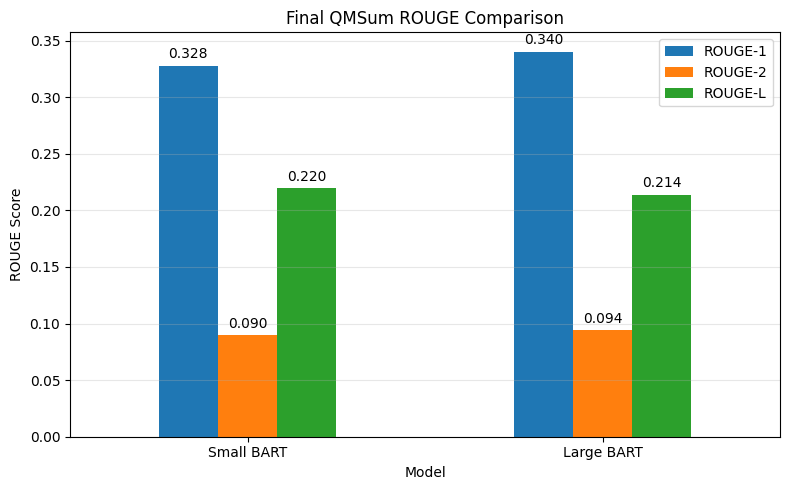

In [18]:
rouge_df = final_df.set_index("Model")[["ROUGE-1", "ROUGE-2", "ROUGE-L"]]

ax = rouge_df.plot(kind="bar", figsize=(8, 5))

plt.title("Final QMSum ROUGE Comparison")
plt.ylabel("ROUGE Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()

## Bar chart: eval loss comparison

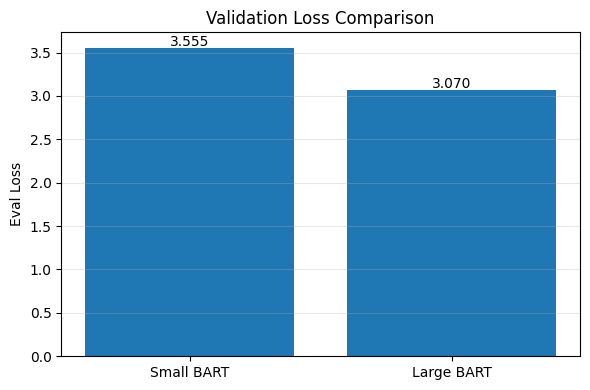

In [19]:
plt.figure(figsize=(6, 4))

bars = plt.bar(final_df["Model"], final_df["Eval Loss"])

plt.title("Validation Loss Comparison")
plt.ylabel("Eval Loss")
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{height:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

## Load sample predictions

In [26]:
def load_predictions(model_dir):
    path = model_dir / "sample_predictions.jsonl"

    if not path.exists():
        print(f"Missing: {path}")
        return []

    rows = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))

    return rows


predictions = {}

for name, path in MODEL_DIRS.items():
    predictions[name] = load_predictions(path)
    print(name, "predictions:", len(predictions[name]))


rouge = evaluate.load("rouge")

sample_rows = []

for name, preds in predictions.items():
    if not preds:
        continue

    generated = [x["generated_summary"] for x in preds]
    references = [x["reference_summary"] for x in preds]

    scores = rouge.compute(
        predictions=generated,
        references=references,
        use_stemmer=True,
    )

    sample_rows.append({
        "Model": name,
        "ROUGE-1": scores["rouge1"],
        "ROUGE-2": scores["rouge2"],
        "ROUGE-L": scores["rougeL"],
        "Samples": len(preds),
    })

sample_df = pd.DataFrame(sample_rows)

display(Markdown("# ROUGE on Saved Sample Predictions"))
display(sample_df)

Small BART predictions: 10
Large BART predictions: 10


# ROUGE on Saved Sample Predictions

,Model,ROUGE-1,ROUGE-2,ROUGE-L,Samples
0,Small BART,0.352119,0.128339,0.255751,10
1,Large BART,0.350908,0.111612,0.245002,10


In [27]:
example_id = 0

small_example = predictions["Small BART"][example_id]
large_example = predictions["Large BART"][example_id]

display(Markdown(f"""
# Qualitative Example {example_id + 1}

## Query
{small_example["query"]}

## Reference Summary
{small_example["reference_summary"]}

## Small BART Generated Summary
{small_example["generated_summary"]}

## Large BART Generated Summary
{large_example["generated_summary"]}
"""))


# Qualitative Example 1

## Query
Summarize the whole meeting.

## Reference Summary
This meeting was the eleventh evidence session on the Children Abolition of Defense of Reasonable Publishment Wales Bill. Barry Hughes was there to answer questions related to the Bill. Six main topics that had been discussed or explained. The first one was how the Bill protected the children in terms of prosecutions. The

## Small BART Generated Summary
The meeting was mainly about the Abolition of Defense of Reasonable Punishment in Wales. Firstly, the Chief Crown Prosecutor for Wales, Kwame Biney, and Iwan Jenkins, who is head of the complex casework unit, Cymru Wales, gave their views on the Bill. Then, the Deputy Prime Minister introduced the Bill

## Large BART Generated Summary
This was the eleventh evidence session on the Children (Abolition of Defence of Reasonable Punishment) (Wales) Bill. The meeting was about the Children, Young People and Education Committee, and it was mainly about the Bill's impact on the CPS and CPS caseworkers. First of all, the group discussed how the law currently stands, and specifically in terms of reasonable punishment, and how the Bill would make things much clearer for parents and professionals. Then, the meeting moved on to a discussion about the impact of the Bill on the children, young people and casework, and then to a further discussion on the Bill itself.
